# Анализ данных

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.style.use('dark_background')
sns.set_theme(style='darkgrid');

In [ ]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [ ]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Колонки Age и Cabin имеют пропуски в обоих наборах данных, Embarked имеет 2 пропуска в трейне, а в тесте пропусков нет.  
Напротив, Fare имеет 1 пропуск в тесте, в трейне пропусков нет

Импорты удачные, перейдем к анализу тренировочных данных

## Анализ тренировочных данных

In [ ]:
train_data.shape

(891, 12)

In [ ]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
train_data.describe(include="str")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [ ]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Колонка PassengerId смысла не несет, поэтому дропнем ее

In [ ]:
train_data = train_data.drop('PassengerId', axis=1)

### Распределение таргета

In [ ]:
pd.DataFrame(train_data['Survived'].value_counts())

,count
Survived,
0,549
1,342


In [ ]:
pd.DataFrame(train_data['Survived'].value_counts(normalize=True))

,proportion
Survived,
0,0.616162
1,0.383838


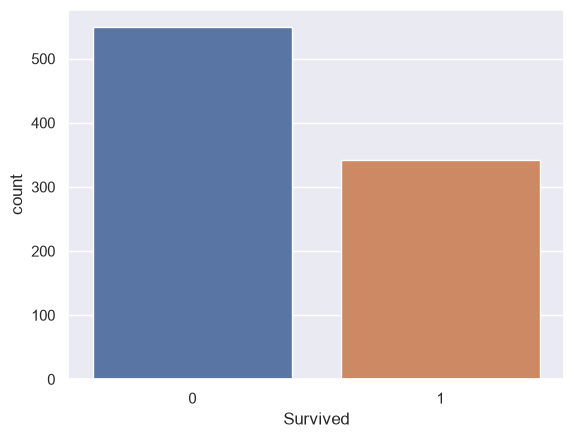

In [ ]:
sns.countplot(data=train_data, x='Survived', hue='Survived', legend=False);

### Анализ категориальных фичей

#### Фича Pclass

In [ ]:
pd.DataFrame(train_data['Pclass'].value_counts())

,count
Pclass,
3,491
1,216
2,184


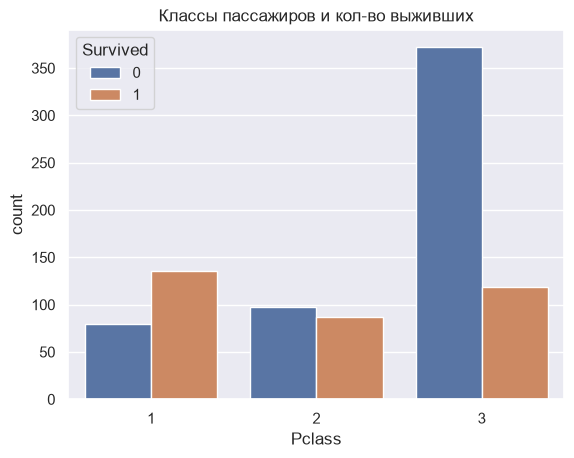

In [ ]:
plt.title('Классы пассажиров и кол-во выживших')
sns.countplot(data=train_data, x='Pclass', hue='Survived');

In [ ]:
pd.DataFrame(train_data.groupby('Pclass')['Survived'].mean())

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


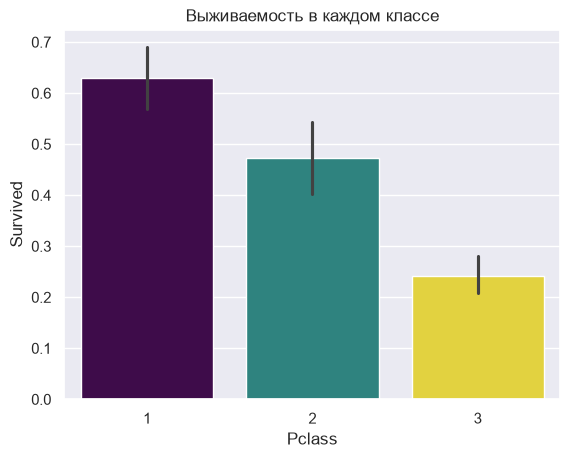

In [ ]:
plt.title('Выживаемость в каждом классе')
sns.barplot(data=train_data, x='Pclass', y='Survived', hue='Pclass', palette='viridis', legend=False);

Очевидно, что пассажиры из более хорошего класса выживали с большей вероятностью

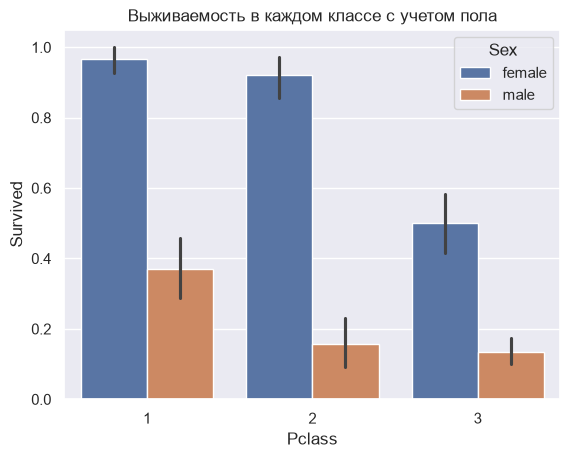

In [ ]:
plt.title('Выживаемость в каждом классе c учетом пола')
sns.barplot(data=train_data, x='Pclass', y='Survived', hue='Sex');

Видим, что вне зависимости от класса женщины выживают чаще мужчин

#### Фича Sex

In [ ]:
pd.DataFrame(train_data['Sex'].value_counts())

,count
Sex,
male,577
female,314


In [ ]:
pd.DataFrame(train_data.groupby('Sex')['Survived'].mean())

,Survived
Sex,
female,0.742038
male,0.188908


Мужчин больше, но выживаемость лучше у женщин

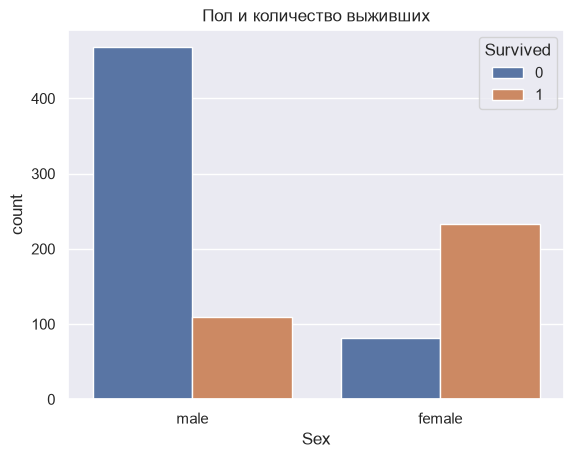

In [ ]:
plt.title('Пол и количество выживших')
sns.countplot(data=train_data, x='Sex', hue='Survived');

#### Фича Embarked

In [ ]:
train_data['Embarked'].isna().sum()

np.int64(2)

Имеется 2 пропуска в данных

In [ ]:
pd.DataFrame(train_data['Embarked'].value_counts())

,count
Embarked,
S,644
C,168
Q,77


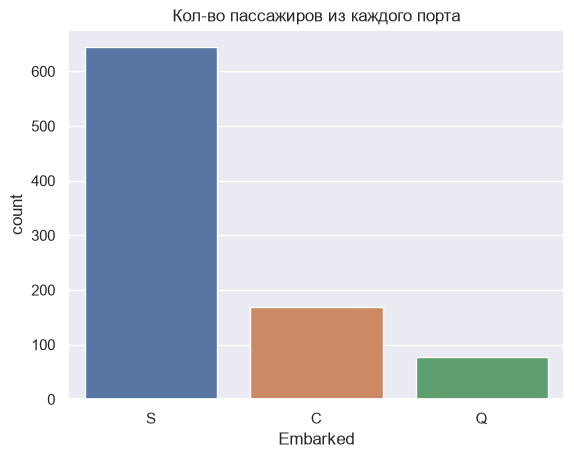

In [ ]:
plt.title('Кол-во пассажиров из каждого порта')
sns.countplot(data=train_data, x='Embarked', hue='Embarked', legend=False);

In [ ]:
pd.DataFrame(train_data.groupby('Embarked')['Survived'].mean())

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


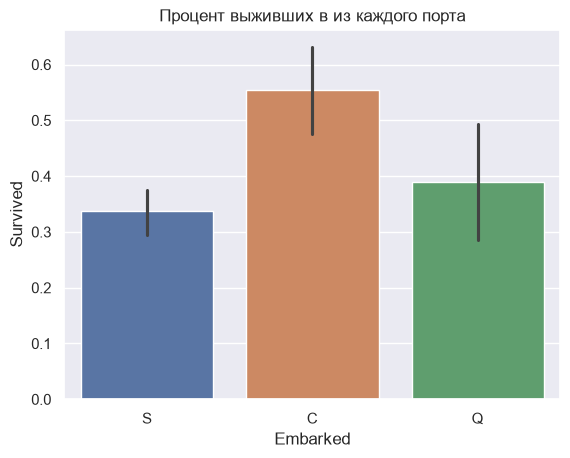

In [ ]:
plt.title('Процент выживших в из каждого порта')
sns.barplot(data=train_data, x='Embarked', y='Survived', hue='Embarked', legend=False);

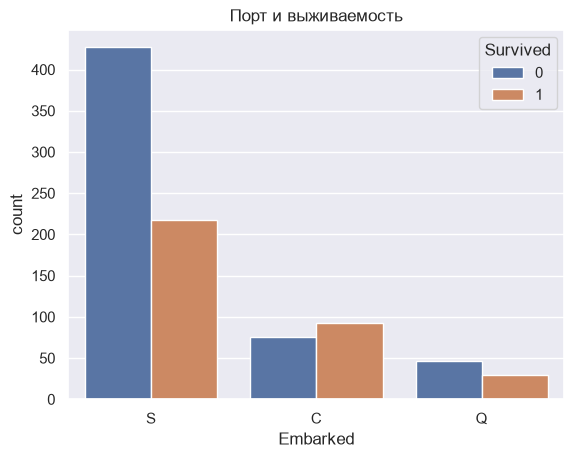

In [ ]:
plt.title('Порт и выживаемость')
sns.countplot(data=train_data, x='Embarked', hue='Survived');

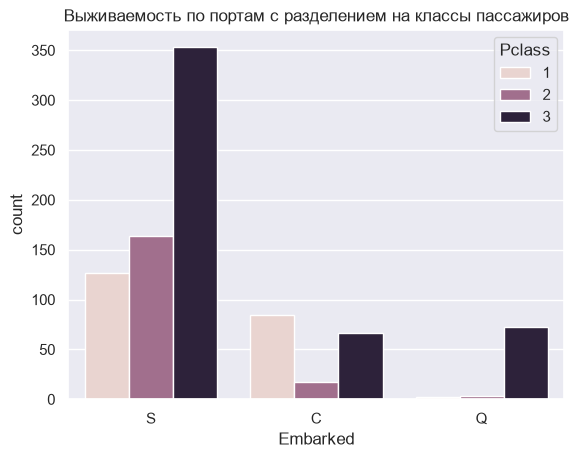

In [ ]:
plt.title('Выживаемость по портам с разделением на классы пассажиров')
sns.countplot(data=train_data, x='Embarked', hue='Pclass');

In [ ]:
pd.DataFrame(train_data[train_data['Embarked'] == 'Q']['Pclass'].value_counts())

,count
Pclass,
3,72
2,3
1,2


Самый многочисленный по пассажирам порт - S, самое большое количесвто людей первого класса из этого порта, однако их доля там меньше относительно других классов  
В порту "C" самая большая доля пассажиров первого класса  
Порт Q самый бичарский и немногочисленный

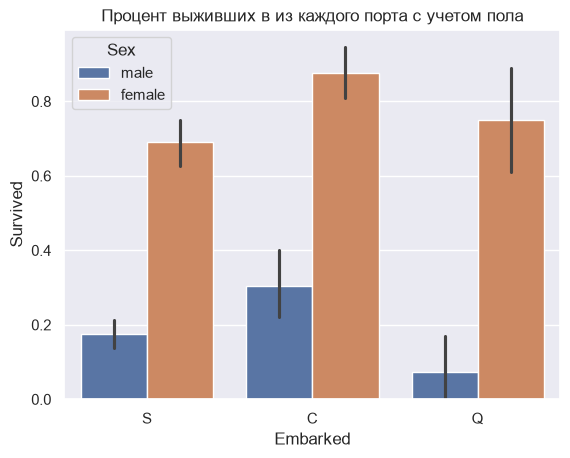

In [ ]:
plt.title('Процент выживших в из каждого порта с учетом пола')
sns.barplot(data=train_data, x='Embarked', y='Survived', hue='Sex');

#### Фича SibSp

In [ ]:
pd.DataFrame(train_data['SibSp'].value_counts())

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


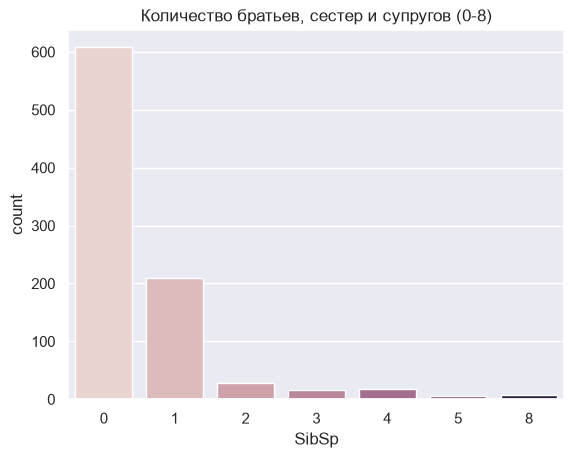

In [ ]:
plt.title('Количество братьев, сестер и супругов (0-8)')
sns.countplot(data=train_data, x='SibSp', hue='SibSp', legend=False);

In [ ]:
pd.DataFrame(train_data.groupby('SibSp')['Survived'].mean())

,Survived
SibSp,
0,0.345395
1,0.535885
2,0.464286
3,0.250000
4,0.166667
5,0.000000
8,0.000000


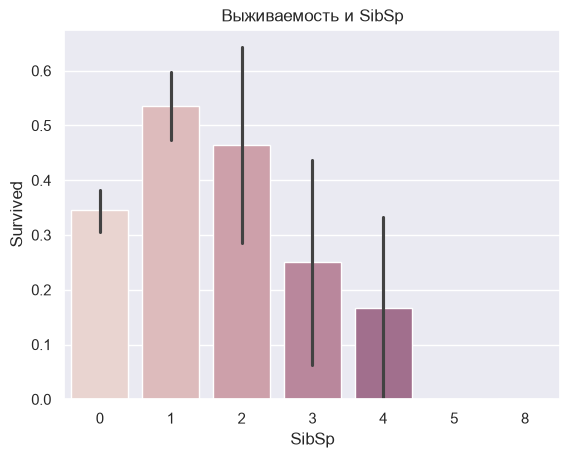

In [ ]:
plt.title('Выживаемость и SibSp')
sns.barplot(data=train_data, x='SibSp', y='Survived', hue='SibSp', legend=False);

In [ ]:
table = pd.crosstab(
    [train_data['Pclass'], train_data['SibSp']],
    train_data['Survived'],
    margins=True
)
table.style.background_gradient(cmap='viridis')


Количество SibSp большее чем 3 встречается только в 3-ем классе, да и SibSp==2 или SibSp==3 в 1-ом и 2-ом классе единичные случаи

Иметь 1 или 2 SibSp в среднем выгоднее, чем 0, однако большее количество SibSp ведет к снижению шансов на выживание, плюс это пересекается с классом

#### Фича Parch

In [ ]:
pd.DataFrame(train_data['Parch'].value_counts())

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


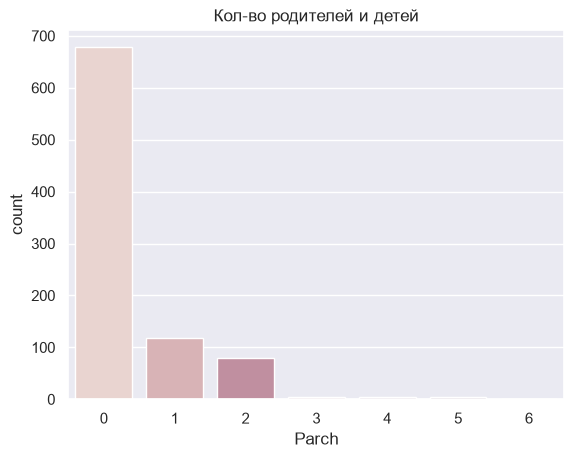

In [ ]:
plt.title('Кол-во родителей и детей')
sns.countplot(data=train_data, x='Parch', hue='Parch', legend=False);

Значения 3-6 встречаются крайне редко 

In [ ]:
pd.DataFrame(train_data.groupby('Parch')['Survived'].mean())

,Survived
Parch,
0,0.343658
1,0.550847
2,0.500000
3,0.600000
4,0.000000
5,0.200000
6,0.000000


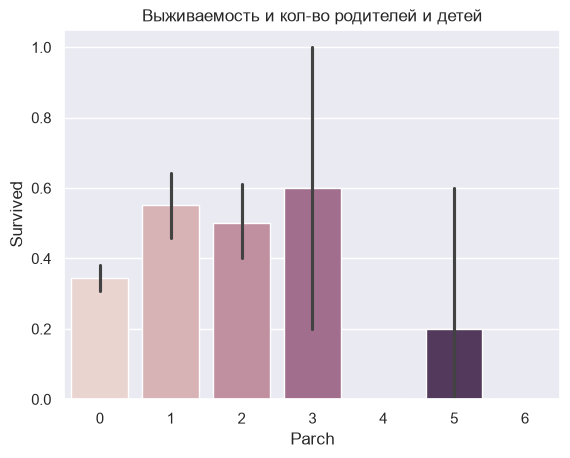

In [ ]:
plt.title('Выживаемость и кол-во родителей и детей')
sns.barplot(data=train_data, x='Parch', y='Survived', hue='Parch', legend=False);

Группы 3-6 малочисленны, поэтому нельзя воспринимать выживаемость для них как нечто значимое

### Анализ числовых фичей

#### Фича Age

In [ ]:
pd.DataFrame(train_data['Age'].describe())

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [ ]:
train_data['Age'].isna().sum()

np.int64(177)

Имеестся 177 пропусков в данных  
из 714 непустых строк минимальный возраст - 0.42 года, максимальный - 80 лет, средний - 29 лет, медиана - 28 лет

In [ ]:
print('Распределение возрастов')
age_bins = pd.cut(train_data['Age'], bins=range(0, 85, 5))
pd.DataFrame(age_bins.value_counts().sort_index())


Распределение возрастов


,count
Age,
"(0, 5]",44
"(5, 10]",20
"(10, 15]",19
"(15, 20]",96
"(20, 25]",122
"(25, 30]",108
"(30, 35]",88
"(35, 40]",67
"(40, 45]",47


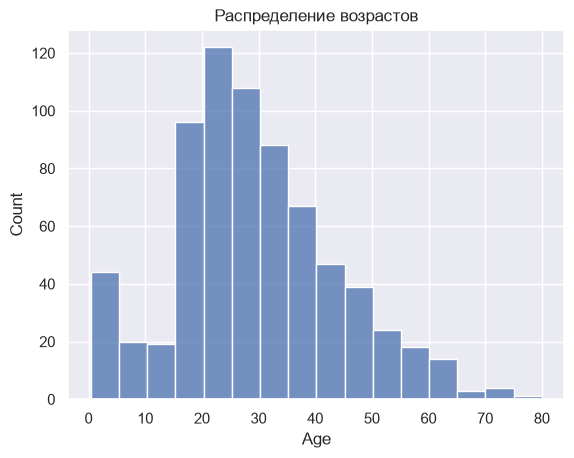

In [ ]:
plt.title('Распределение возрастов')
sns.histplot(data=train_data, x='Age', bins=16);

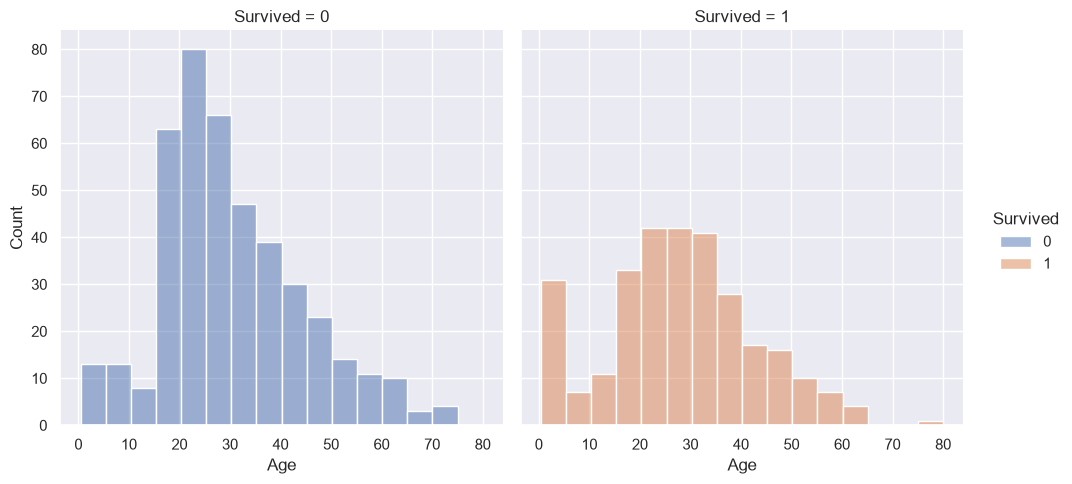

In [ ]:
sns.displot(data=train_data, x='Age', col='Survived', bins=16, hue='Survived');

В целом тренды визуально выглядят схоже для обеих групп выживших и не выживших в силу численности в каждом бине, но можем замететить, что выживаемость большая для детей 0-5 лет

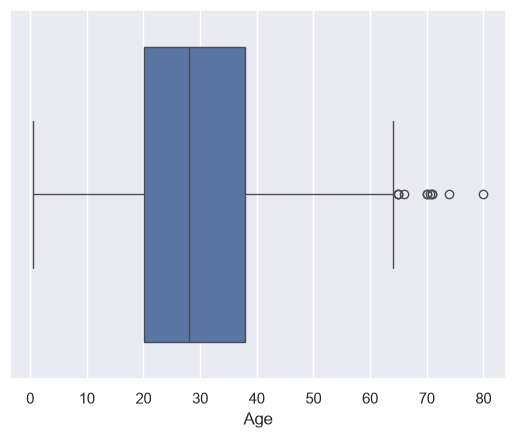

In [ ]:
sns.boxplot(data=train_data, x='Age');

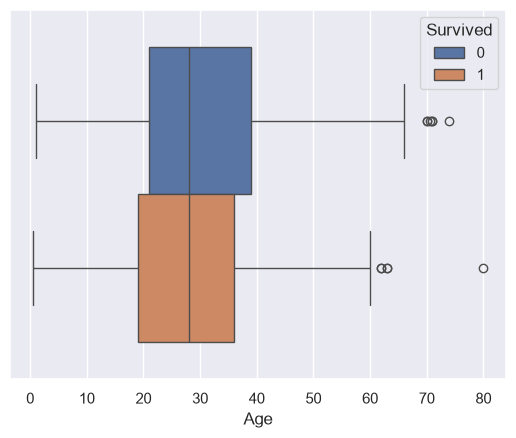

In [ ]:
sns.boxplot(data=train_data, x='Age', hue='Survived');

Доля выживших смещена левее, есть выброс выжившего 80-ти летнего пассажира

In [ ]:
train_data[train_data['Age'] > 76]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


80-ти летний мужчина из 1-го класса

С пропусками разберемся на этапе обработки данных

#### Фича Fare

In [ ]:
pd.DataFrame(train_data['Fare'].describe())

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


Минимальное fare - 0, максимальное 512, среднее 32, медиана 14, огромная разница между 75 и 100 квартилем, распределение перекошено

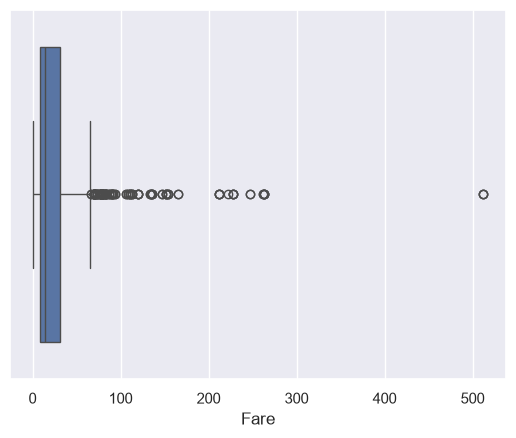

In [ ]:
sns.boxplot(data=train_data, x='Fare');

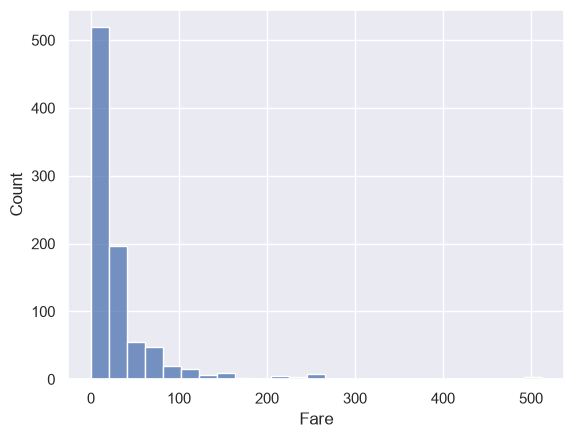

In [ ]:
sns.histplot(data=train_data, x='Fare', bins=25);

Распределение перекошено вправа, есть сильные выбросы, гипотеза, что это богачи из 1-2 классов

In [ ]:
q75 = train_data['Fare'].quantile(0.75)
iqr = train_data['Fare'].quantile(0.75) - train_data['Fare'].quantile(0.25)
threshold = q75 + 1.5 * iqr
threshold

np.float64(65.6344)

In [ ]:
train_data[train_data['Fare'] > threshold].sort_values('Fare', ascending=False)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
679,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
27,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
341,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
...,...,...,...,...,...,...,...,...,...,...,...
324,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.5500,NaN,S
369,1,1,"Aubart, Mme. Leontine Pauline",female,24.0,0,0,PC 17477,69.3000,B35,C
641,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.3000,B35,C
336,0,1,"Pears, Mr. Thomas Clinton",male,29.0,1,0,113776,66.6000,C2,S


In [ ]:
train_data[train_data['Fare'] > threshold]['Pclass'].value_counts()


Pclass
1    104
3      7
2      5
Name: count, dtype: int64

In [ ]:
train_data[train_data['Fare'] > threshold]['Pclass'].value_counts(normalize=True)

Pclass
1    0.896552
3    0.060345
2    0.043103
Name: proportion, dtype: float64

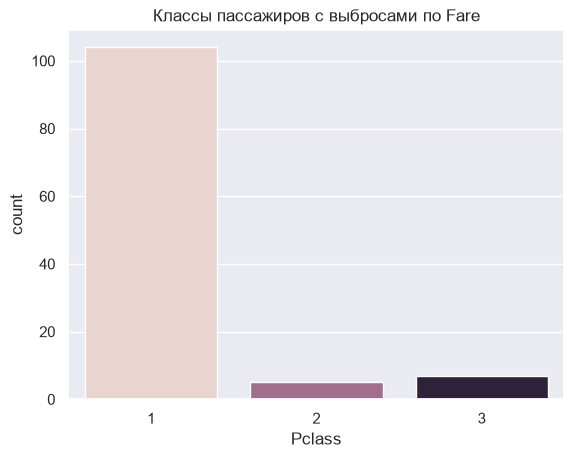

In [ ]:
plt.title('Классы пассажиров с выбросами по Fare')
sns.countplot(data=train_data[train_data['Fare'] > threshold], x='Pclass', hue='Pclass', legend=False);

Действительно, бОльшая часть выбросов по Fare это пассажиры первого класса

### Строковые фичи

#### Фича Name

In [ ]:
train_data['Name'].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: str

Можно достать сокращения типа Mr, Mrs и тд, это поможет в заполнении пропусков в колонке Age

In [ ]:
train_data['Title'] = train_data['Name'].str.extract(r' ([A-Za-z]+)\.')
train_data['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [ ]:
train_data['Title'].value_counts().sum()

np.int64(891)

In [ ]:
len(train_data)

891

У каждого пассажира есть свой титул

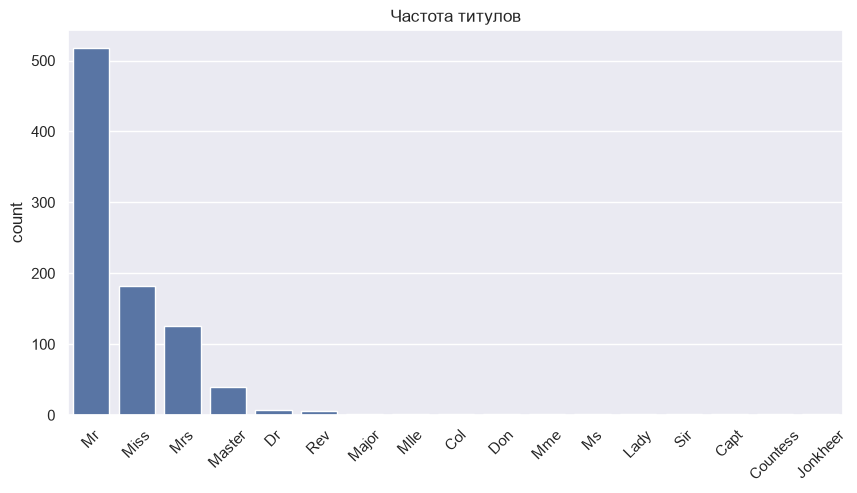

In [ ]:
plt.figure(figsize=(10, 5))
plt.title('Частота титулов')
sns.countplot(data=train_data, x='Title', order=train_data['Title'].value_counts().index)
plt.xlabel(None)
plt.xticks(rotation=45);


In [ ]:
print('Титулы по полу')
pd.crosstab(train_data['Title'], train_data['Sex']).style.background_gradient(cmap='viridis')

Титулы по полу


Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [ ]:
print('Количество и средняя выживаемость по титулам')
train_data.groupby('Title')['Survived'].agg(['count', 'mean']).sort_values('count', ascending=False).style.background_gradient(cmap='viridis')


Количество и средняя выживаемость по титулам


,count,mean
Title,,
Mr,517,0.156673
Miss,182,0.697802
Mrs,125,0.792000
Master,40,0.575000
Dr,7,0.428571
Rev,6,0.000000
Mlle,2,1.000000
Major,2,0.500000
Col,2,0.500000


In [ ]:
print('Титулы по классам пассажиров')
pd.crosstab(train_data['Title'], train_data['Pclass']).style.background_gradient(cmap='viridis')


Титулы по классам пассажиров


Pclass,1,2,3
Title,,,
Capt,1,0,0
Col,2,0,0
Countess,1,0,0
Don,1,0,0
Dr,5,2,0
Jonkheer,1,0,0
Lady,1,0,0
Major,2,0,0
Master,3,9,28


In [ ]:
print('Сводная таблица')
title_summary = pd.concat([
    pd.crosstab(train_data['Title'], train_data['Sex']),
    pd.crosstab(train_data['Title'], train_data['Pclass']),
    train_data.groupby('Title')['Survived'].agg(['count', 'mean'])
], axis=1, keys=['Sex', 'Pclass', 'Survived'])

title_summary.style.background_gradient(cmap='viridis')



Сводная таблица


*Информация от клода*  
Значения титулов:

- Mr — мистер (взрослый мужчина)
- Mrs — миссис (замужняя женщина)
- Miss — мисс (незамужняя женщина/девушка)
- Master — обращение к мальчику/юноше
- Dr — доктор
- Rev — Reverend, священник
- Major, Col, Capt — воинские звания (майор, полковник, капитан)
- Mlle — Mademoiselle, французский аналог Miss
- Mme — Madame, французский аналог Mrs
- Ms — нейтральное обращение к женщине (не указывает семейное положение)
- Don — испанский/итальянский почётный титул (аналог "сэр")
- Lady, Sir, Countess, Jonkheer — дворянские титулы  

"Опечаток" в смысле ошибок нет — все титулы валидны, регэксп сработал корректно. Но есть смысловые дубликаты из-за языка: Mlle и Mme по сути то же самое, что Miss и Mrs, просто на французском — их обычно объединяют при фиче-инжиниринге. Также редкие титулы (Dr, Rev, военные, дворянские) часто группируют в общую категорию "Rare" из-за малого числа наблюдений.

Name сама по себе бесполезна (уникальна для каждого), но из неё извлекается титул Title, который несёт сигнал о поле, возрасте и социальном статусе, полезная фича

#### Фича Ticket

Посмотрим на размер групп пассажиров (есть пассажиры с повторяющимися билетами)

In [ ]:
ticket_counts = train_data['Ticket'].value_counts()
train_data['TicketGroupSize'] = train_data['Ticket'].map(ticket_counts)
train_data['TicketGroupSize'].value_counts().sort_index()

TicketGroupSize
1    547
2    188
3     63
4     44
5     10
6     18
7     21
Name: count, dtype: int64

<Axes: title={'center': 'Размер группы по тикету и выживаемость'}, xlabel='TicketGroupSize', ylabel='Survived'>

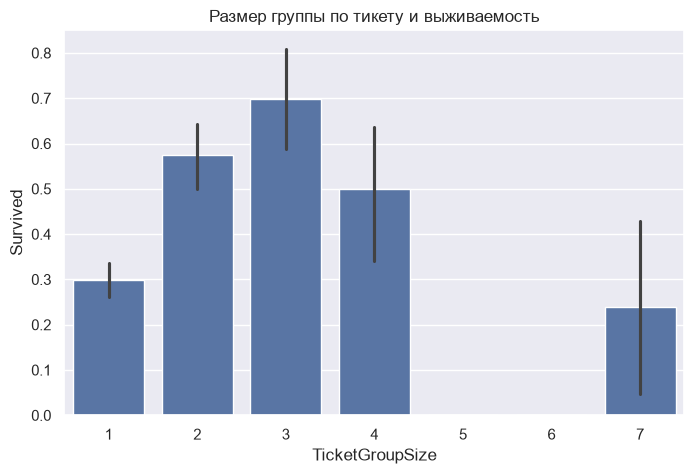

In [ ]:
plt.figure(figsize=(8, 5))
plt.title('Размер группы по тикету и выживаемость')
sns.barplot(data=train_data, x='TicketGroupSize', y='Survived')

In [ ]:
train_data['FarePerPerson'] = train_data['Fare'] / train_data['TicketGroupSize']
train_data[['Fare', 'TicketGroupSize', 'FarePerPerson']].head(10)

,Fare,TicketGroupSize,FarePerPerson
0,7.2500,1,7.25000
1,71.2833,1,71.28330
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000
5,8.4583,1,8.45830
6,51.8625,1,51.86250
7,21.0750,4,5.26875
8,11.1333,3,3.71110
9,30.0708,2,15.03540


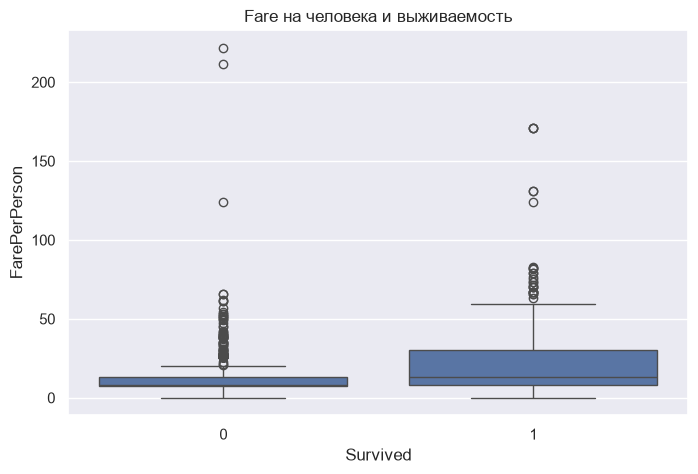

In [ ]:
plt.figure(figsize=(8, 5))
plt.title('Fare на человека и выживаемость')
sns.boxplot(data=train_data, x='Survived', y='FarePerPerson');

In [ ]:
def extract_prefix(ticket):
    parts = ticket.replace('.', '').replace('/', '').split()
    if len(parts) > 1 and not parts[0].isdigit():
        return parts[0].upper()
    return 'NONE'

train_data['TicketPrefix'] = train_data['Ticket'].apply(extract_prefix)
train_data['TicketPrefix'].value_counts()

TicketPrefix
NONE       665
PC          60
CA          41
A5          21
SOTONOQ     15
STONO       12
SCPARIS     11
WC          10
A4           7
STONO2       6
SOC          6
C            5
FCC          5
PP           3
WEP          3
SCAH         3
SOPP         3
SWPP         2
PPP          2
SOTONO2      2
SCA4         1
SP           1
SOP          1
FA           1
SCOW         1
SC           1
AS           1
FC           1
CASOTON      1
Name: count, dtype: int64

In [ ]:
train_data['TicketPrefix'].unique()

<StringArray>
[     'A5',      'PC',  'STONO2',    'NONE',      'PP',      'CA', 'SCPARIS',
    'SCA4',      'A4',      'SP',     'SOC',      'WC', 'SOTONOQ',     'WEP',
   'STONO',       'C',     'SOP',      'FA',     'FCC',    'SWPP',    'SCOW',
     'PPP',      'SC',    'SCAH',      'AS',    'SOPP',      'FC', 'SOTONO2',
 'CASOTON']
Length: 29, dtype: str

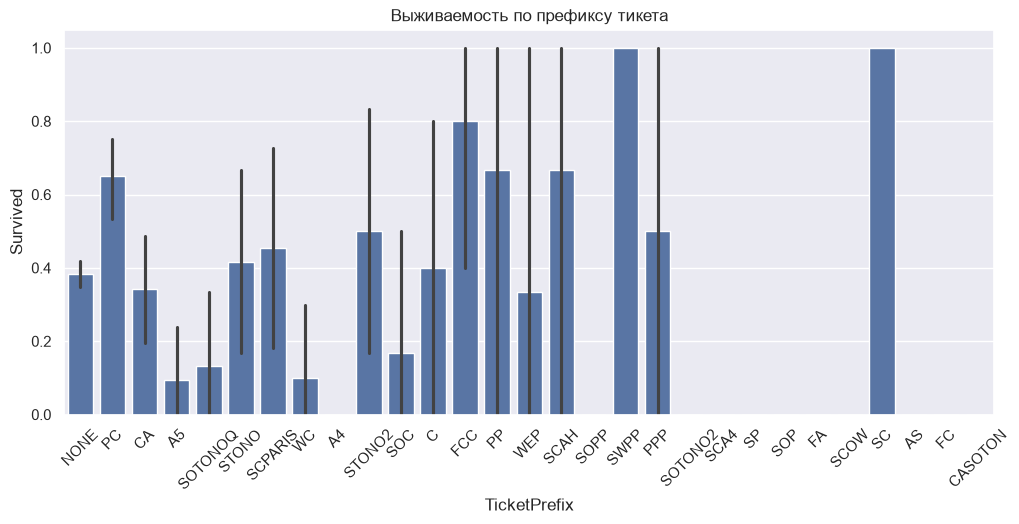

In [ ]:
plt.figure(figsize=(12, 5))
plt.title('Выживаемость по префиксу тикета')
sns.barplot(data=train_data, x='TicketPrefix', y='Survived', order=train_data['TicketPrefix'].value_counts().index)
plt.xticks(rotation=45);


In [ ]:
print('Префикс тикета по классам')
pd.crosstab(train_data['TicketPrefix'], train_data['Pclass']).style.background_gradient(cmap='viridis')

Префикс тикета по классам


Pclass,1,2,3
TicketPrefix,,,
A4,0,0,7
A5,0,0,21
AS,0,0,1
C,0,0,5
CA,0,19,22
CASOTON,0,1,0
FA,0,0,1
FC,1,0,0
FCC,0,5,0


Ticket номер сам по себе не несёт смысла, но размер группы по тикету TicketGroupSize и производный FarePerPerson дают полезный сигнал, префикс тикета слабее и менее интерпретируем

#### Фича Cabin

In [ ]:
print('Пропуски в Cabin')
train_data['Cabin'].isna().sum()

Пропуски в Cabin


np.int64(687)

In [ ]:
print('Палуба (первая буква каюты)')
train_data['Deck'] = train_data['Cabin'].str[0]
train_data['Deck'].value_counts(dropna=False)

Палуба (первая буква каюты)


Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [ ]:
print('Палуба по классам пассажиров')
pd.crosstab(train_data['Deck'], train_data['Pclass']).style.background_gradient(cmap='viridis')

Палуба по классам пассажиров


Pclass,1,2,3
Deck,,,
A,15,0,0
B,47,0,0
C,59,0,0
D,29,4,0
E,25,4,3
F,0,8,5
G,0,0,4
T,1,0,0


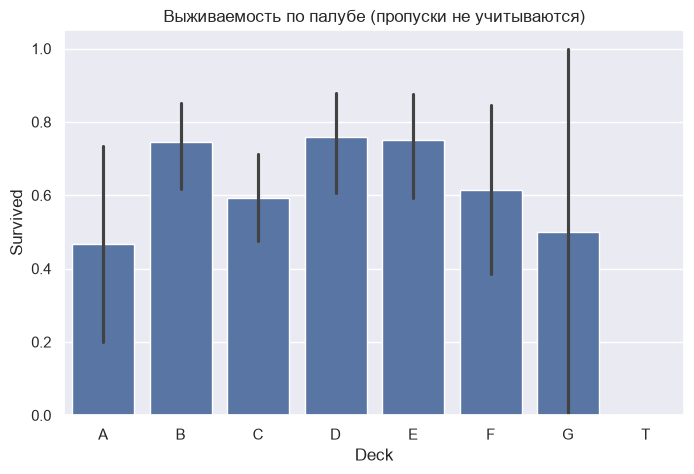

In [ ]:
plt.figure(figsize=(8, 5))
plt.title('Выживаемость по палубе (пропуски не учитываются)')
sns.barplot(data=train_data[train_data['Deck'].notna()], x='Deck', y='Survived', order=sorted(train_data['Deck'].dropna().unique()));

In [ ]:
train_data['HasCabin'] = train_data['Cabin'].notna().astype(int)
print('Наличие каюты и выживаемость')
train_data.groupby('HasCabin')['Survived'].agg(['count', 'mean'])

Наличие каюты и выживаемость


,count,mean
HasCabin,,
0,687,0.299854
1,204,0.666667


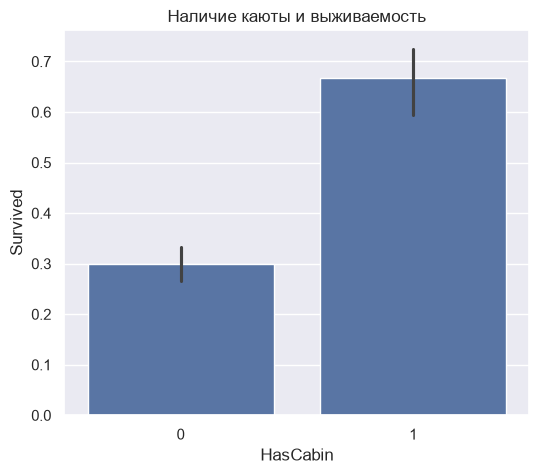

In [ ]:
plt.figure(figsize=(6, 5))
plt.title('Наличие каюты и выживаемость')
sns.barplot(data=train_data, x='HasCabin', y='Survived');

Cabin имеет 77% пропусков, поэтому сама колонка малопригодна напрямую, но извлечённая палуба Deck коррелирует с классом, а сам факт наличия каюты HasCabin сильный прокси-признак, те, у кого известна каюта, выживали чаще, вероятно коррелирует с классом/местом на корабле

### Матрица корреляций

In [ ]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,TicketGroupSize,FarePerPerson,TicketPrefix,Deck,HasCabin
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,7.2500,A5,NaN,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,71.2833,PC,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,7.9250,STONO2,NaN,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,26.5500,NONE,C,1
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,8.0500,NONE,NaN,0


In [ ]:
print('Числовые колонки')
numeric_cols = train_data.select_dtypes(include=[np.number]).columns
numeric_cols

Числовые колонки


Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'TicketGroupSize', 'FarePerPerson', 'HasCabin'],
      dtype='str')

In [ ]:
print('Матрица корреляций')
corr = train_data[numeric_cols].corr()

Матрица корреляций


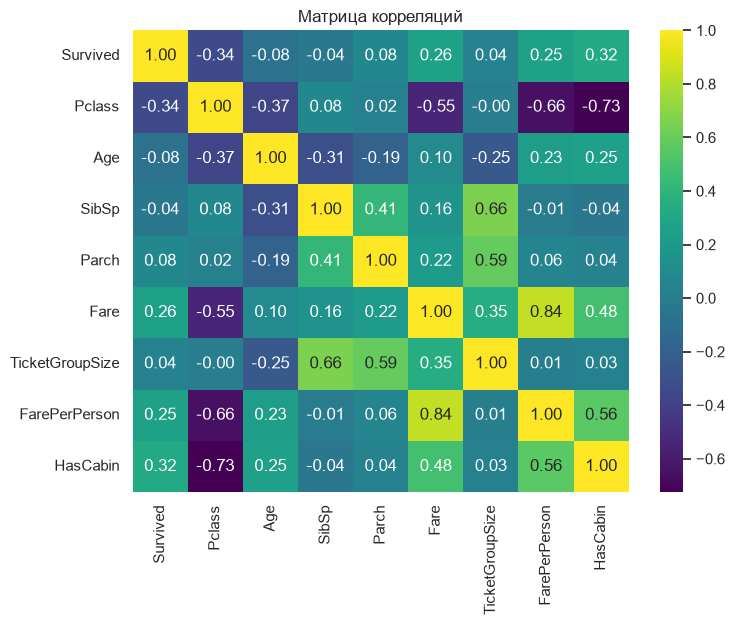

In [ ]:
plt.figure(figsize=(8, 6))
plt.title('Матрица корреляций')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis');

In [ ]:
print('Количество уникальных значений по числовым колонкам (проверка на константность)')
train_data[numeric_cols].nunique()

Количество уникальных значений по числовым колонкам (проверка на константность)


Survived             2
Pclass               3
Age                 88
SibSp                7
Parch                7
Fare               248
TicketGroupSize      7
FarePerPerson      248
HasCabin             2
dtype: int64

In [ ]:
print('Пары с сильной корреляцией (|corr| > 0.5)')
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]

pairs = corr_pairs.reset_index()
pairs.columns = ['Feature1', 'Feature2', 'Corr']
pairs['pair_key'] = pairs.apply(lambda row: tuple(sorted([row['Feature1'], row['Feature2']])), axis=1)
pairs = pairs.drop_duplicates('pair_key').drop(columns='pair_key')
pairs = pairs[pairs['Corr'] > 0.5].sort_values('Corr', ascending=False).reset_index(drop=True)

pairs.style.background_gradient(cmap='viridis', subset=['Corr'])

Пары с сильной корреляцией (|corr| > 0.5)


,Feature1,Feature2,Corr
0,Fare,FarePerPerson,0.839037
1,Pclass,HasCabin,0.725541
2,SibSp,TicketGroupSize,0.661622
3,Pclass,FarePerPerson,0.655559
4,Parch,TicketGroupSize,0.593076
5,FarePerPerson,HasCabin,0.560773
6,Pclass,Fare,0.549500


### Сравнение распределений в тренировочных и тестовых данных

In [ ]:
combined = pd.concat([
    train_data.assign(dataset='train'),
    test_data.assign(dataset='test')
], ignore_index=True)

print('Размеры train/test')
combined['dataset'].value_counts()

Размеры train/test


dataset
train    891
test     418
Name: count, dtype: int64

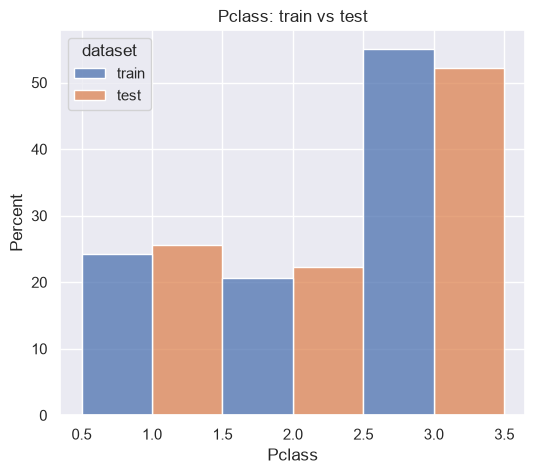

In [ ]:
plt.figure(figsize=(6, 5))
plt.title('Pclass: train vs test')
sns.histplot(data=combined, x='Pclass', hue='dataset', stat='percent', common_norm=False, discrete=True, multiple='dodge');

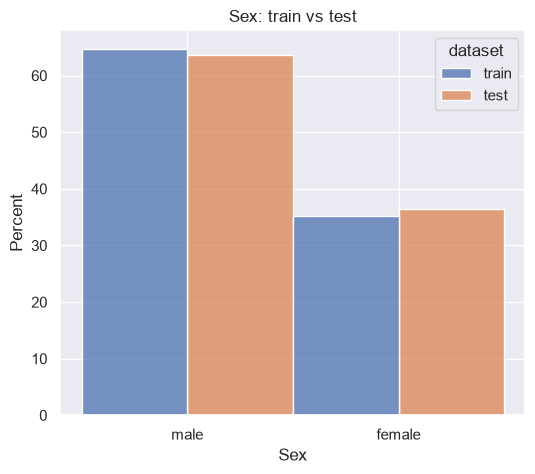

In [ ]:
plt.figure(figsize=(6, 5))
plt.title('Sex: train vs test')
sns.histplot(data=combined, x='Sex', hue='dataset', stat='percent', common_norm=False, multiple='dodge');

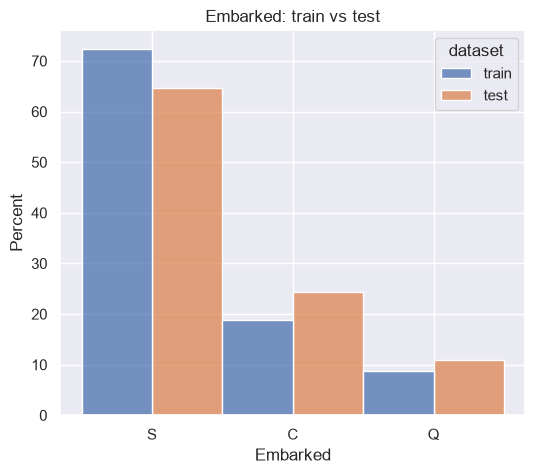

In [ ]:
plt.figure(figsize=(6, 5))
plt.title('Embarked: train vs test')
sns.histplot(data=combined, x='Embarked', hue='dataset', stat='percent', common_norm=False, multiple='dodge');

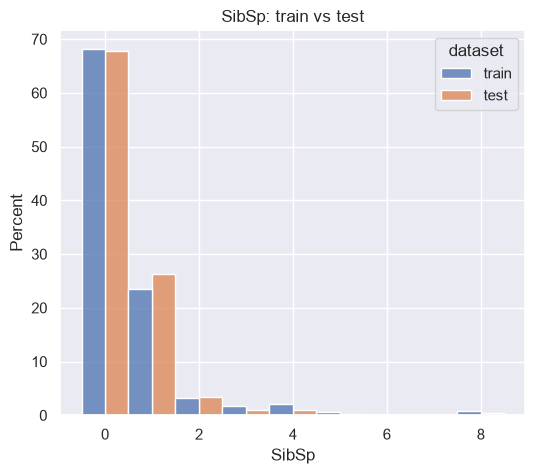

In [ ]:
plt.figure(figsize=(6, 5))
plt.title('SibSp: train vs test')
sns.histplot(data=combined, x='SibSp', hue='dataset', stat='percent', common_norm=False, discrete=True, multiple='dodge');

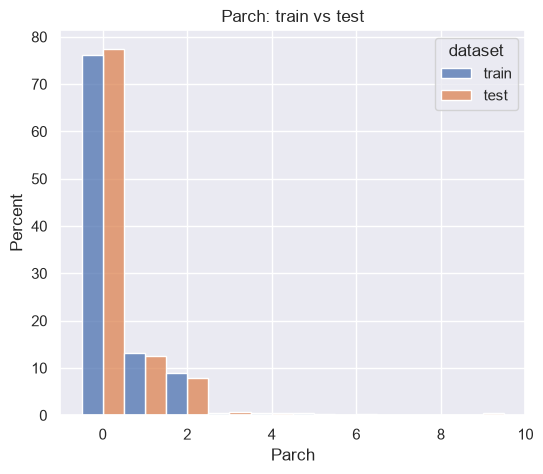

In [ ]:
plt.figure(figsize=(6, 5))
plt.title('Parch: train vs test')
sns.histplot(data=combined, x='Parch', hue='dataset', stat='percent', common_norm=False, discrete=True, multiple='dodge');

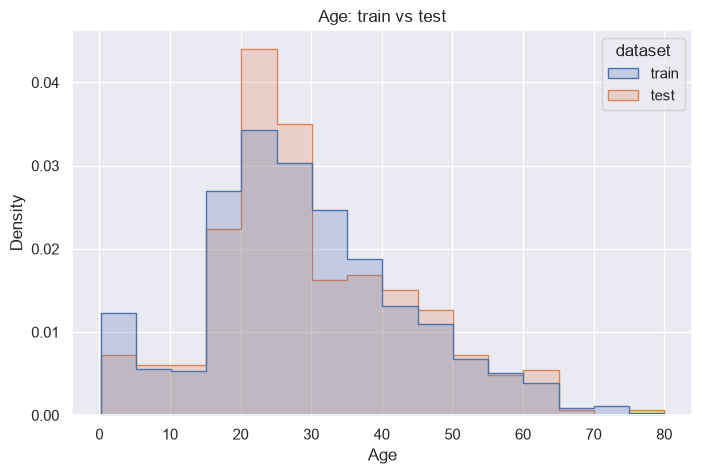

In [ ]:
plt.figure(figsize=(8, 5))
plt.title('Age: train vs test')
sns.histplot(data=combined, x='Age', hue='dataset', stat='density', common_norm=False, bins=16, element='step');

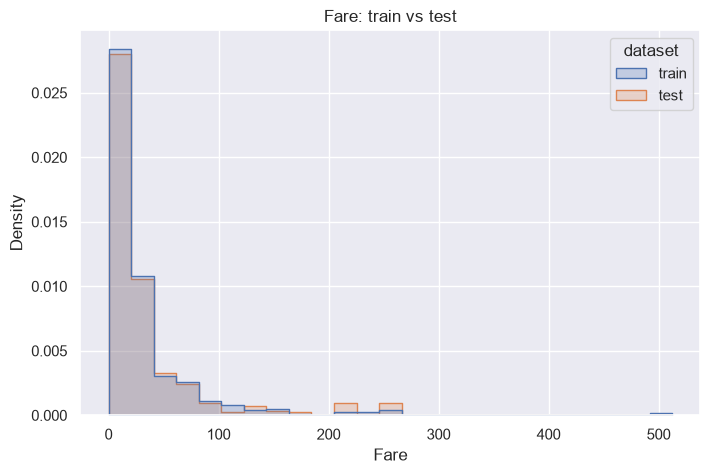

In [ ]:
plt.figure(figsize=(8, 5))
plt.title('Fare: train vs test')
sns.histplot(data=combined, x='Fare', hue='dataset', stat='density', common_norm=False, bins=25, element='step');

В трейне и тесте схожее распределение данных

Сначала хотел построить модели в этом же блокноте, но ограничусь только анализом данных